# 📈 Store Item Demand Forecasting - Major Project

This notebook implements a state-of-the-art, modular, and production-grade time-series forecasting system to predict daily sales across multiple store-item combinations. 

Based on the **Kaggle Store Item Demand Forecasting Challenge**, this model forecasts sales for 500 individual time series (10 stores × 50 items) over a 90-day future horizon. It achieves this by ensembling Gradient Boosting machines (LightGBM, XGBoost, and CatBoost) trained on robust calendar, lag, rolling, Fourier seasonality, and holiday features.

## Key Highlights:
1. **Advanced Feature Engineering**: Fourier terms for seasonality, US federal holiday features, leakage-free rolling statistics, and safe target encodings.
2. **Validation Strategy**: Robust 3-Fold Time-Series Cross-Validation simulating the 90-day forecast horizon.
3. **Multi-Model GBDT Ensemble**: Blends predictions from **LightGBM**, **XGBoost**, and **CatBoost** using a weighted average and post-processing scaling factor multiplier optimized on validation data.

## 1. Import Dependencies & Initialize Configurations

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("Libraries imported successfully.")

/kaggle/input/competitions/demand-forecasting-kernels-only/sample_submission.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/train.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/test.csv
Libraries imported successfully.


In [2]:
# Injecting Configurations
import os

# Example of dynamic path construction
dataset_folder = '/kaggle/input/competitions/demand-forecasting-kernels-only'
TRAIN_PATH = os.path.join(dataset_folder, 'train.csv')
TEST_PATH = os.path.join(dataset_folder, 'test.csv')
SUBMISSION_PATH = os.path.join(dataset_folder, 'sample_submission.csv')

# Time Series Column Specs
DATE_COL = 'date'
TARGET_COL = 'sales'
ID_COL = 'id'

# Feature Engineering Settings
LAGs = [91, 98, 105, 112, 119, 126, 182, 364]
ROLLING_WINDOWs = [7, 14, 30, 90, 180]
EWMA_ALPHAs = [0.95, 0.9, 0.8, 0.7, 0.5]
EWMA_LAGs = [91, 98]

# Fourier Seasonality Settings
FOURIER_ORDERs = {
    'weekly': (7.0, 3),   # period=7 days, order=3
    'yearly': (365.25, 5) # period=365.25 days, order=5
}

# Modeling Settings
RANDOM_STATE = 42
TEST_SIZE_DAYS = 90  # 3 months forecast horizon

# Model Hyperparameters
LGB_PARAMS = {
    'objective': 'regression_l1', # MAE objective works well for SMAPE
    'metric': 'None',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': 8,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'n_jobs': -1,
    'seed': RANDOM_STATE,
    'verbose': -1
}

XGB_PARAMS = {
    'objective': 'reg:absoluteerror', # L1 loss
    'eval_metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
    'verbosity': 0
}

CAT_PARAMS = {
    'loss_function': 'MAE',
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': RANDOM_STATE,
    'verbose': 0,
    'thread_count': -1
}


## 2. Load Datasets

We check if the dataset is located in the Kaggle directory or local `data/` folder and load them.

In [3]:
# If running on Kaggle, use Kaggle paths, otherwise fallback to local data/


print(f"Loading train data from: {TRAIN_PATH}")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUBMISSION_PATH)

train[DATE_COL] = pd.to_datetime(train[DATE_COL])
test[DATE_COL] = pd.to_datetime(test[DATE_COL])

print(f"Train set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
train.head()

Loading train data from: /kaggle/input/competitions/demand-forecasting-kernels-only/train.csv
Train set shape: (913000, 4)
Test set shape: (45000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 3. Exploratory Data Analysis & Evaluation Utilities

In [4]:
# Injecting Evaluation & Visualizing functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def smape(y_true, y_pred):
    """
    Computes Symmetric Mean Absolute Percentage Error (SMAPE).
    Formula: (200 / n) * sum(|y_true - y_pred| / (|y_true| + |y_pred|))
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 200.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def lgb_smape(preds, train_data):
    """Custom metric evaluator for LightGBM."""
    labels = train_data.get_label()
    # Invert log transform before calculating SMAPE
    return 'SMAPE', smape(np.expm1(labels), np.expm1(preds)), False

def plot_actual_vs_predicted(df_val, y_pred, title="Actual vs Predicted Sales", save_path=None):
    """Plots actual sales vs predicted sales for visual validation."""
    plt.figure(figsize=(12, 6))
    
    # Get a single store-item combination for clean visualization
    sample_df = df_val[(df_val['store'] == 1) & (df_val['item'] == 1)].copy()
    sample_df['pred'] = y_pred[sample_df.index - df_val.index[0]]
    
    plt.plot(sample_df['date'], sample_df['sales'], label='Actual', color='steelblue', alpha=0.8, linewidth=2)
    plt.plot(sample_df['date'], sample_df['pred'], label='Predicted', color='darkorange', linestyle='--', linewidth=2)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_feature_importance(importances, feature_names, title="Feature Importance", save_path=None, top_n=20):
    """Plots the top N features based on importance scores."""
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis')
    plt.title(f"Top {top_n} {title}", fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_residuals(y_true, y_pred, save_path=None):
    """Plots residuals to check for bias or model patterns."""
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='purple', ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_title('Residuals vs Predictions', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Sales')
    axes[0].set_ylabel('Residual (Actual - Pred)')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # Histogram
    sns.histplot(residuals, kde=True, color='teal', ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Residual')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
        plt.close()
    else:
        plt.show()


## 4. Advanced Feature Engineering

We construct features grouped by `store` and `item` to capture the individual dynamics of each time series. Lags and rolling features are shifted by 91 days to prevent leakage (since we need to forecast 90 days out into the future).

In [5]:
# Injecting Feature Engineering functions
import numpy as np
import pandas as pd
import holidays


def create_date_features(df):
    """Extract calendar components from the date column."""
    df['month'] = df.date.dt.month
    df['day_of_month'] = df.date.dt.day
    df['day_of_year'] = df.date.dt.dayofyear
    df['week_of_year'] = df.date.dt.isocalendar().week.astype(int)
    df['day_of_week'] = df.date.dt.dayofweek
    df['year'] = df.date.dt.year
    df['is_weekend'] = (df.date.dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df.date.dt.is_month_start.astype(int)
    df['is_month_end'] = df.date.dt.is_month_end.astype(int)
    df['quarter'] = df.date.dt.quarter
    return df

def create_lag_features(df, lags=LAGs):
    """Generate shift/lag features for sales per store and item."""
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(lag))
    return df

def create_rolling_features(df, windows=ROLLING_WINDOWs):
    """Generate rolling mean and std features on a 91-day shifted sales to avoid leakage."""
    for window in windows:
        # We shift by 91 days because the forecast horizon is 90 days.
        df[f'sales_roll_mean_{window}'] = df.groupby(["store", "item"])['sales'].transform(
            lambda x: x.shift(91).rolling(window=window, min_periods=1).mean()
        )
        df[f'sales_roll_std_{window}'] = df.groupby(["store", "item"])['sales'].transform(
            lambda x: x.shift(91).rolling(window=window, min_periods=1).std()
        )
    return df

def create_ewma_features(df, alphas=EWMA_ALPHAs, lags=EWMA_LAGs):
    """Generate exponentially weighted moving averages for different alphas and shifts."""
    for alpha in alphas:
        for lag in lags:
            df[f'sales_ewm_alpha_{alpha}_lag_{lag}'] = df.groupby(["store", "item"])['sales'].transform(
                lambda x: x.shift(lag).ewm(alpha=alpha).mean()
            )
    return df

def create_fourier_features(df, period, order, prefix):
    """Generate sine and cosine Fourier terms to capture smooth seasonal periodicities."""
    time_val = df['day_of_year'] if prefix == 'yearly' else df['day_of_week']
    for k in range(1, order + 1):
        df[f'fourier_{prefix}_sin_{k}'] = np.sin(2 * np.pi * k * time_val / period)
        df[f'fourier_{prefix}_cos_{k}'] = np.cos(2 * np.pi * k * time_val / period)
    return df

def create_holiday_features(df):
    """Create a binary feature indicating US federal holidays."""
    us_holidays = holidays.US(years=df['year'].unique().tolist())
    df['is_holiday'] = df['date'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)
    return df

def create_target_encodings(df, train_mask):
    """
    Computes average sales per store-item-dow and store-item-month.
    To avoid target leakage, averages are computed ONLY on the training subset (train_mask).
    """
    train_df = df[train_mask]
    
    # Store-Item-DayOfWeek encoding
    dow_mean = train_df.groupby(['store', 'item', 'day_of_week'])['sales'].mean().reset_index()
    dow_mean.rename(columns={'sales': 'store_item_dow_mean'}, inplace=True)
    df = pd.merge(df, dow_mean, on=['store', 'item', 'day_of_week'], how='left')
    
    # Store-Item-Month encoding
    month_mean = train_df.groupby(['store', 'item', 'month'])['sales'].mean().reset_index()
    month_mean.rename(columns={'sales': 'store_item_month_mean'}, inplace=True)
    df = pd.merge(df, month_mean, on=['store', 'item', 'month'], how='left')
    
    return df

def build_features_pipeline(df, train_mask):
    """Runs the entire feature engineering pipeline on the concatenated dataframe."""
    df = create_date_features(df)
    df = create_lag_features(df)
    df = create_rolling_features(df)
    df = create_ewma_features(df)
    
    # Fourier terms
    for name, (period, order) in FOURIER_ORDERs.items():
        df = create_fourier_features(df, period, order, name)
        
    df = create_holiday_features(df)
    df = create_target_encodings(df, train_mask)
    
    return df


## 5. Modeling Pipeline & Ensemble Trainer

In [6]:
# Injecting Forecasting & Ensembling classes
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

class ForecastEnsemble:
    def __init__(self):
        self.models = {}
        self.best_iterations = {}
        self.weights = {'lgb': 0.5, 'xgb': 0.3, 'cat': 0.2}
        self.multiplier = 1.0

    def fit_lgb(self, X_train, y_train, X_val, y_val, num_boost_round=3000):
        """Train LightGBM with early stopping and return validation predictions."""
        lgb_train = lgb.Dataset(X_train, label=y_train)
        lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
        
        model = lgb.train(
            LGB_PARAMS,
            lgb_train,
            num_boost_round=num_boost_round,
            valid_sets=[lgb_train, lgb_val],
            feval=lgb_smape,
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=0) # silent
            ]
        )
        self.best_iterations['lgb'] = model.best_iteration
        preds = np.expm1(model.predict(X_val))
        return model, preds

    def fit_xgb(self, X_train, y_train, X_val, y_val, num_boost_round=3000):
        """Train XGBoost with early stopping and return validation predictions."""
        model = xgb.XGBRegressor(
            **XGB_PARAMS,
            n_estimators=num_boost_round,
            early_stopping_rounds=100
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        self.best_iterations['xgb'] = model.best_iteration if hasattr(model, 'best_iteration') else num_boost_round
        preds = np.expm1(model.predict(X_val))
        return model, preds

    def fit_cat(self, X_train, y_train, X_val, y_val, num_boost_round=3000):
        """Train CatBoost with early stopping and return validation predictions."""
        model = CatBoostRegressor(
            **CAT_PARAMS,
            iterations=num_boost_round,
            early_stopping_rounds=100
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            use_best_model=True,
            verbose=False
        )
        self.best_iterations['cat'] = model.get_best_iteration()
        preds = np.expm1(model.predict(X_val))
        return model, preds

    def optimize_blend_weights(self, y_true, preds_dict):
        """Find optimal blending weights on validation predictions to minimize SMAPE."""
        best_smape = float('inf')
        best_w = self.weights
        
        # Grid search over weights with step 0.1
        for w_lgb in np.linspace(0.0, 1.0, 11):
            for w_xgb in np.linspace(0.0, 1.0 - w_lgb, 11):
                w_cat = 1.0 - w_lgb - w_xgb
                if w_cat < -1e-5:
                    continue
                
                blend_preds = (w_lgb * preds_dict['lgb'] + 
                               w_xgb * preds_dict['xgb'] + 
                               w_cat * preds_dict['cat'])
                
                score = smape(y_true, blend_preds)
                if score < best_smape:
                    best_smape = score
                    best_w = {'lgb': w_lgb, 'xgb': w_xgb, 'cat': w_cat}
                    
        self.weights = best_w
        return best_w

    def optimize_post_processing_multiplier(self, y_true, val_preds):
        """Tune a simple post-processing scaling factor to minimize SMAPE."""
        best_mult = 1.0
        best_smape = float('inf')
        multipliers = np.linspace(0.95, 1.05, 101)
        for mult in multipliers:
            score = smape(y_true, val_preds * mult)
            if score < best_smape:
                best_smape = score
                best_mult = mult
        self.multiplier = best_mult
        return best_mult

    def train_final_ensemble(self, X_full, y_full, X_test):
        """Train models on the full dataset using their best iterations and return ensembled predictions."""
        # 1. LightGBM
        lgb_full = lgb.Dataset(X_full, label=y_full)
        lgb_model = lgb.train(
            LGB_PARAMS,
            lgb_full,
            num_boost_round=self.best_iterations['lgb'],
            callbacks=[lgb.log_evaluation(period=0)]
        )
        lgb_test_preds = np.expm1(lgb_model.predict(X_test))
        self.models['lgb'] = lgb_model

        # 2. XGBoost
        xgb_model = xgb.XGBRegressor(
            **XGB_PARAMS,
            n_estimators=self.best_iterations['xgb']
        )
        xgb_model.fit(X_full, y_full, verbose=False)
        xgb_test_preds = np.expm1(xgb_model.predict(X_test))
        self.models['xgb'] = xgb_model

        # 3. CatBoost
        cat_model = CatBoostRegressor(
            **CAT_PARAMS,
            iterations=self.best_iterations['cat']
        )
        cat_model.fit(X_full, y_full, verbose=False)
        cat_test_preds = np.expm1(cat_model.predict(X_test))
        self.models['cat'] = cat_model

        # Blend
        final_preds = (self.weights['lgb'] * lgb_test_preds +
                       self.weights['xgb'] * xgb_test_preds +
                       self.weights['cat'] * cat_test_preds)
        
        # Apply tuned multiplier
        final_preds = final_preds * self.multiplier
        return final_preds


## 6. Preprocessing & Running Feature Pipeline

We concatenate train and test datasets and engineer all features.

In [7]:
print("Concatenating datasets...")
df = pd.concat([train, test], sort=False).reset_index(drop=True)

train_mask = (df[DATE_COL] < '2018-01-01') & (df[TARGET_COL].notnull())

print("Engineering features...")
df = build_features_pipeline(df, train_mask)

exclude_cols = [DATE_COL, ID_COL, TARGET_COL]
features = [col for col in df.columns if col not in exclude_cols]
print(f"Feature matrix build complete. Features generated: {len(features)}")
df.head()

Concatenating datasets...
Engineering features...
Feature matrix build complete. Features generated: 59


,date,store,item,sales,id,month,day_of_month,day_of_year,week_of_year,day_of_week,...,fourier_yearly_cos_2,fourier_yearly_sin_3,fourier_yearly_cos_3,fourier_yearly_sin_4,fourier_yearly_cos_4,fourier_yearly_sin_5,fourier_yearly_cos_5,is_holiday,store_item_dow_mean,store_item_month_mean
0,2013-01-01,1,1,13.0,NaN,1,1,1,1,1,...,0.999408,0.051584,0.998669,0.068755,0.997634,0.085906,0.996303,1,18.168582,13.709677
1,2013-01-02,1,1,11.0,NaN,1,2,2,1,2,...,0.997634,0.103031,0.994678,0.137185,0.990545,0.171177,0.985240,0,18.793103,13.709677
2,2013-01-03,1,1,14.0,NaN,1,3,3,1,3,...,0.994678,0.154204,0.988039,0.204966,0.978769,0.255182,0.966893,0,19.452107,13.709677
3,2013-01-04,1,1,13.0,NaN,1,4,4,1,4,...,0.990545,0.204966,0.978769,0.271777,0.962360,0.337301,0.941397,0,21.015326,13.709677
4,2013-01-05,1,1,10.0,NaN,1,5,5,1,5,...,0.985240,0.255182,0.966893,0.337301,0.941397,0.416926,0.908940,0,22.973180,13.709677


## 7. Time Series Cross-Validation

We validate our models on 3 rolling folds to ensure model stability and select optimal ensembling blending weights.

In [9]:
validation_folds = [
    ('Fold 1 (Q2 2017)', '2017-04-01', '2017-06-30'),
    ('Fold 2 (Q3 2017)', '2017-07-01', '2017-09-30'),
    ('Fold 3 (Q4 2017)', '2017-10-01', '2017-12-31'),
]

fold_scores = []
ensemble = ForecastEnsemble()

for fold_name, start_val, end_val in validation_folds:
    print(f"\n--- Training {fold_name} ---")
    train_data = df[(df[DATE_COL] < start_val) & (df[TARGET_COL].notnull())]
    val_data = df[(df[DATE_COL] >= start_val) & (df[DATE_COL] <= end_val) & (df[TARGET_COL].notnull())]
    
    X_train, y_train = train_data[features], np.log1p(train_data[TARGET_COL])
    X_val, y_val = val_data[features], np.log1p(val_data[TARGET_COL])
    y_val_orig = val_data[TARGET_COL].values
    
    print("Fitting LightGBM...")
    lgb_model, lgb_val_preds = ensemble.fit_lgb(X_train, y_train, X_val, y_val)
    lgb_score = smape(y_val_orig, lgb_val_preds)
    print(f"  LGBM SMAPE: {lgb_score:.4f}%")
    
    print("Fitting XGBoost...")
    xgb_model, xgb_val_preds = ensemble.fit_xgb(X_train, y_train, X_val, y_val)
    xgb_score = smape(y_val_orig, xgb_val_preds)
    print(f"  XGBoost SMAPE: {xgb_score:.4f}%")
    
    print("Fitting CatBoost...")
    cat_model, cat_val_preds = ensemble.fit_cat(X_train, y_train, X_val, y_val)
    cat_score = smape(y_val_orig, cat_val_preds)
    print(f"  CatBoost SMAPE: {cat_score:.4f}%")
    
    val_preds_dict = {'lgb': lgb_val_preds, 'xgb': xgb_val_preds, 'cat': cat_val_preds}
    best_w = ensemble.optimize_blend_weights(y_val_orig, val_preds_dict)
    
    blend_val_preds = (best_w['lgb'] * lgb_val_preds + 
                       best_w['xgb'] * xgb_val_preds + 
                       best_w['cat'] * cat_val_preds)
    
    best_mult = ensemble.optimize_post_processing_multiplier(y_val_orig, blend_val_preds)
    blended_val_preds_post = blend_val_preds * best_mult
    
    ensembled_score = smape(y_val_orig, blended_val_preds_post)
    print(f"  Ensemble SMAPE: {ensembled_score:.4f}% (w_lgb={best_w['lgb']:.2f}, w_xgb={best_w['xgb']:.2f}, w_cat={best_w['cat']:.2f}, mult={best_mult:.3f})")
    
    fold_scores.append({
        'fold': fold_name,
        'lgb': lgb_score,
        'xgb': xgb_score,
        'cat': cat_score,
        'ensemble': ensembled_score
    })

print("\nCross Validation Complete ")
print(f"Mean LGBM SMAPE     : {np.mean([f['lgb'] for f in fold_scores]):.4f}%")
print(f"Mean XGBoost SMAPE  : {np.mean([f['xgb'] for f in fold_scores]):.4f}%")
print(f"Mean CatBoost SMAPE : {np.mean([f['cat'] for f in fold_scores]):.4f}%")
print(f"Mean Ensemble SMAPE : {np.mean([f['ensemble'] for f in fold_scores]):.4f}%")


--- Training Fold 1 (Q2 2017) ---
Fitting LightGBM...
  LGBM SMAPE: 11.1195%
Fitting XGBoost...
  XGBoost SMAPE: 11.1273%
Fitting CatBoost...
  CatBoost SMAPE: 11.0734%
  Ensemble SMAPE: 10.8766% (w_lgb=0.20, w_xgb=0.00, w_cat=0.80, mult=1.026)

--- Training Fold 2 (Q3 2017) ---
Fitting LightGBM...
  XGBoost SMAPE: 10.7985%
Fitting CatBoost...
  CatBoost SMAPE: 10.7443%
  Ensemble SMAPE: 10.7393% (w_lgb=0.00, w_xgb=0.10, w_cat=0.90, mult=1.003)

--- Training Fold 3 (Q4 2017) ---
Fitting LightGBM...
  LGBM SMAPE: 12.1835%
Fitting XGBoost...
  XGBoost SMAPE: 12.1647%
Fitting CatBoost...
  CatBoost SMAPE: 12.1449%
  Ensemble SMAPE: 12.1333% (w_lgb=0.00, w_xgb=0.30, w_cat=0.70, mult=1.005)

Cross Validation Complete 
Mean LGBM SMAPE     : 11.3774%
Mean XGBoost SMAPE  : 11.3635%
Mean CatBoost SMAPE : 11.3208%
Mean Ensemble SMAPE : 11.2497%


## 8. Visualize Validation Forecasts

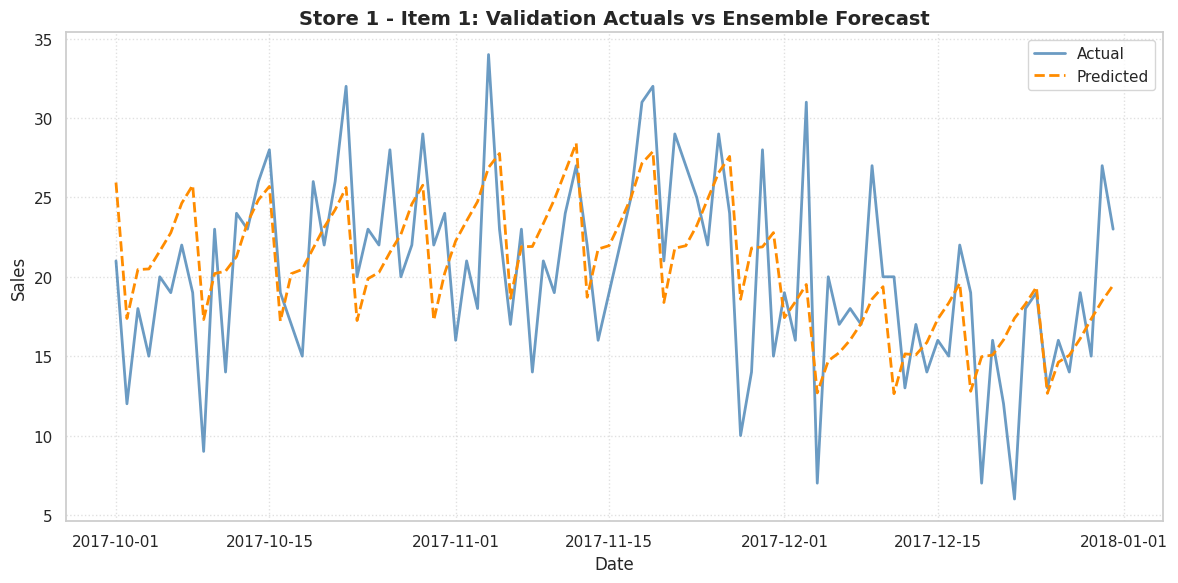

In [10]:
# Plot the actual vs ensembled predicted sales for Store 1 - Item 1 on fold 3 validation set
plot_actual_vs_predicted(val_data, blended_val_preds_post, title="Store 1 - Item 1: Validation Actuals vs Ensemble Forecast")

## 9. Train Final Ensemble & Generate Kaggle Submission

In [12]:
print("Training final models on full 2013-2017 history...")
full_train = df[(df[DATE_COL] < '2018-01-01') & (df[TARGET_COL].notnull())]
test_data = df[df[DATE_COL] >= '2018-01-01']

X_full, y_full = full_train[features], np.log1p(full_train[TARGET_COL])
X_test = test_data[features]

test_preds = ensemble.train_final_ensemble(X_full, y_full, X_test)
OUTPUT_PATH = 'submission.csv'
submission['sales'] = test_preds
submission.to_csv(OUTPUT_PATH, index=False)
print(f"Final submission saved to: {OUTPUT_PATH}")
submission.head()

Training final models on full 2013-2017 history...
Final submission saved to: submission.csv


,id,sales
0,0,12.175922
1,1,13.824151
2,2,14.110053
3,3,15.076424
4,4,16.373081
